# Weak Rate Coverage

In [73]:
import pynucastro as pyna
import matplotlib.pyplot as plt

Read in all the weak rates with a specific ordering. Later entries have higher priorities, i.e. `suzuki` rate has the highest priority which will override overlapping rates from earlier sources.

In [2]:
tl = pyna.TabularLibrary(ordering=["ffn", "oda", "langanke", "pruet_fuller", "suzuki"])

In [3]:
rates = tl.get_rates()

Now let’s make a plot that shows the source for each rate, colored by the reactant.

We’ll plot in terms of $(𝑍,𝑁)$, so let’s find the bounds of the rate coverage, and round it to the nearest 5

In [4]:
high_Z = max(r.products[0].Z for r in rates)
high_N = max(r.products[0].N for r in rates)
max_size = 5 * (max(high_Z, high_N) // 5 + 1)

In [5]:
ffn_rates = [r for r in rates if r.rfile_name.startswith("ffn")]
oda_rates = [r for r in rates if r.rfile_name.startswith("oda")]
langanke_rates = [r for r in rates if r.rfile_name.startswith("langanke")]
pruet_rates = [r for r in rates if r.rfile_name.startswith("pruet")]
suzuki_rates = [r for r in rates if r.rfile_name.startswith("suzuki")]

We also want to plot stable reactants for reference. Let's get ReacLib rates and plot the stable nuclei involved.

In [6]:
rl = pyna.ReacLibLibrary()
rates = rl.get_rates()
stable_nuc = []
for r in rates:
    for reactant in r.reactants:
        if reactant.tau == "stable":
            stable_nuc.append(reactant)

In [92]:
def plot_weak_rate_coverage(ax, weak_type):
    assert weak_type in ["beta", "electron"]

    # fig, ax = plt.subplot()
    
    # Plot weak rate reactants
    ax.scatter([r.reactants[0].N for r in ffn_rates if r.weak_type.startswith(weak_type)],
               [r.reactants[0].Z for r in ffn_rates if r.weak_type.startswith(weak_type)],
               marker="s", color="tab:blue", label="FFN")

    ax.scatter([r.reactants[0].N for r in oda_rates if r.weak_type.startswith(weak_type)],
               [r.reactants[0].Z for r in oda_rates if r.weak_type.startswith(weak_type)],
               marker="s", color="tab:cyan", label="Oda")
    
    ax.scatter([r.reactants[0].N for r in langanke_rates if r.weak_type.startswith(weak_type)],
               [r.reactants[0].Z for r in langanke_rates if r.weak_type.startswith(weak_type)],
               marker="s", color="tab:green", label="Langanke")
    
    ax.scatter([r.reactants[0].N for r in pruet_rates if r.weak_type.startswith(weak_type)],
               [r.reactants[0].Z for r in pruet_rates if r.weak_type.startswith(weak_type)],
               marker="s", color="tab:orange", label="Pruet & Fuller")
    
    ax.scatter([r.reactants[0].N for r in suzuki_rates if r.weak_type.startswith(weak_type)],
               [r.reactants[0].Z for r in suzuki_rates if r.weak_type.startswith(weak_type)],
               marker="s", color="tab:red", label="Suzuki")

    # Plot stable nuclei
    ax.scatter([nuc.N for nuc in stable_nuc], [nuc.Z for nuc in stable_nuc],
               marker="s", facecolors="none", edgecolors="k", label="Stable")
    
    # Z = N line
    ax.plot([0, max_size], [0, max_size],
            ls="--", color="k", alpha=0.8)
    
    ax.text(0.75*max_size, 0.75*max_size, r"$Z=N$", 
            fontsize=16, rotation=45, ha="center", va="bottom")
    
    # magic number lines
    magic_numbers = [2, 8, 20, 28, 50, 82, 126]
    vertical_position = {2: ((2, 2), (0, 10)),
                         8: ((8, 8), (0, 24)),
                         20: ((20, 20), (5, 32)),
                         28: ((28, 28), (12, 38)),
                         50: ((50, 50), (18, 52)),
                         82: ((82, 82), (25, 55))}
    horizontal_position = {2: ((0, 10), (2, 2)),
                           8: ((0, 24), (8, 8)),
                           20: ((5, 42), (20, 20)),
                           28: ((16, 52), (28, 28))}
    
    for m in magic_numbers:
        if m > max_size:
            continue
        try:
            # Draw vertical line
            ax.plot(vertical_position[m][0], vertical_position[m][1], ls=":",
                    color="gray", alpha=0.7)
        
            # Add labeling
            ax.text(vertical_position[m][0][1], vertical_position[m][1][1], 
                    f"{m}", color="k", va="bottom", ha="center", fontsize=16)
            
            # Draw horizontal line
            ax.plot(horizontal_position[m][0], horizontal_position[m][1], ls=":",
                    color="gray", alpha=0.7)
        
            # Add labeling
            ax.text(horizontal_position[m][0][1], horizontal_position[m][1][1], 
                    f"{m}", color="k", va="center", ha="left", fontsize=16)
        except KeyError:
            continue
    
    # ax.legend(frameon=False, fontsize=16)
    
    # ax.set_xlabel("N", fontsize=16)
    # ax.set_ylabel("Z", fontsize=16)
    
    ax.set_xlim(-1, max_size)
    ax.set_ylim(-1, max_size)
    
    ax.set_aspect("equal")
    
    ax.tick_params(which="both", direction="in",
                   labelsize=16, size=6,
                   top=True, left=True, bottom=True, right=True)

    if weak_type == "beta":
        title = r"$\beta^{-}$ decay + $e^{+}$ capture"
        # outname = "beta-decay-coverage.png"
    elif weak_type == "electron":
        title = r"$\beta^{+}$ decay + $e^{-}$ capture"
        
        # outname = "electron-capture-coverage.png"

    # Add title
    # ax.set_title(title)
    ax.text(0.1, 0.9, title,
            transform=ax.transAxes, ha="left", va="top", fontsize=20,
            bbox=dict(facecolor="white", edgecolor="black", linewidth=1.2,
                      boxstyle="square,pad=0.5"))

    # fig.set_size_inches(8, 8)
    # fig.savefig(outname, format="png", bbox_inches="tight")

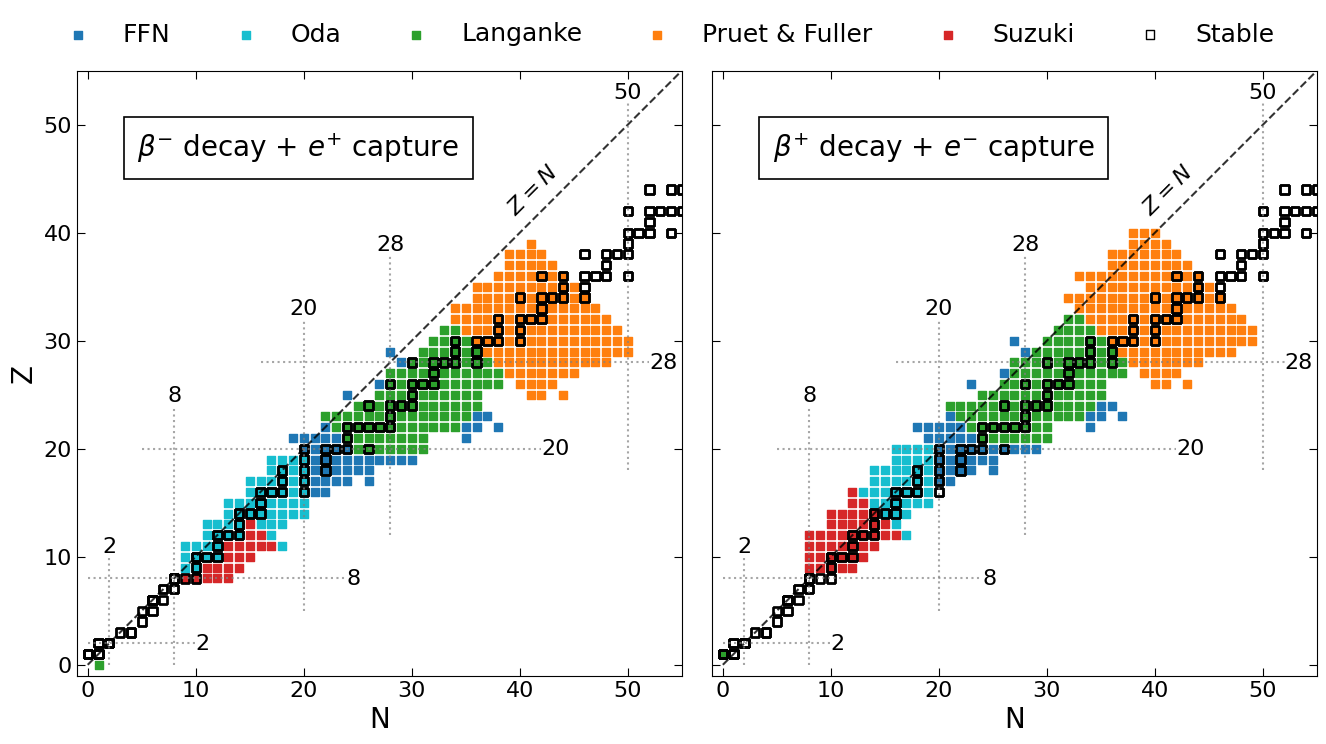

In [95]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(16, 8))

plot_weak_rate_coverage(axs[0], "beta")
plot_weak_rate_coverage(axs[1], "electron")

axs[0].set_ylabel("Z", fontsize=20)

for ax in axs:
    ax.set_xlabel("N", fontsize=20)

# single legend for whole figure
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", 
           ncol=6, frameon=False, fontsize=18)

fig.subplots_adjust(top=0.95, wspace=0.05)

fig.savefig("weak-rate-coverage.png", format="png", bbox_inches="tight")